In [1]:
import numpy as np

def QuadGaussRuleInfo(rule, point):
    """
    INPUT: pth rule, point 
    PROCESS: calculates Legendre-Gauss in 2x2 
    OUTPUT: (xi, eta), weight (multiplied)
    """
    # allows for specifying amount of points per axis
        
    if np.size(rule) == 2:
        p1, p2 = rule
    else:
        p1 = p2 = rule
    
    if np.size(point) == 2:
        i1, i2 = point
    else:
        k = point
    
        # visiting counter
        i2 = (k - 1) // p1 + 1
        i1 = k - p1 * (i2 - 1)
            
    xi, w1 = LineGaussRuleInfo(p1, i1)
    eta, w2 = LineGaussRuleInfo(p2, i2)
    
    info = np.array([xi, eta], dtype=float), w1 * w2

    return info

def LineGaussRuleInfo(rule, point):
    """
    INPUT: pth rule, ith point 
    PROCESS: calculates the ith point of the Legendre-Gauss quadrature for a pth rule (up to the 4th rule)
    OUTPUT: point, weight as "info"
    """

    g2 = np.array([-1, 1]) / np.sqrt(3)

    w3 = np.array([5/9, 8/9, 5/9])
    g3 = np.array([-np.sqrt(3/5), 0, np.sqrt(3/5)])

    w4 = np.array([
        1/2 - np.sqrt(5/6)/6,
        1/2 + np.sqrt(5/6)/6,
        1/2 + np.sqrt(5/6)/6,
        1/2 - np.sqrt(5/6)/6
    ])

    g4 = np.array([
        -np.sqrt((3 + 2*np.sqrt(6/5))/7),
        -np.sqrt((3 - 2*np.sqrt(6/5))/7),
         np.sqrt((3 - 2*np.sqrt(6/5))/7),
         np.sqrt((3 + 2*np.sqrt(6/5))/7)
    ])

    # python index
    i = point - 1

    if rule == 1:
        info = np.array([0.0, 2.0])

    elif rule == 2:
        info = np.array([g2[i], 1.0])

    elif rule == 3:
        info = np.array([g3[i], w3[i]])

    elif rule == 4:
        info = np.array([g4[i], w4[i]])
    return info




def Quad4IsoPShapeFunDer(ncoor, qcoor):
    """
    INPUT: ncoor (node coordinates), qcoor (parametric coordinates)
    PROCESS:
    OUTPUT: Nf (shape functions), dNx, dNy (derivatives of the shape functions), Jdet (determinant of the jacobian)
    """
    xi, eta = qcoor
    
    Nf = 0.25 * np.array([
        (1-xi)*(1-eta),
        (1+xi)*(1-eta),
        (1+xi)*(1+eta),
        (1-xi)*(1+eta)
    ])

    dNxi = 0.25 * np.array([
        -(1-eta),
        (1-eta),
        (1+eta),
        -(1+eta)
    ])

    dNeta = 0.25 * np.array([
        -(1-xi),
        -(1+xi),
        (1+xi),
        (1-xi)
    ])

    ncoor = np.asarray(ncoor)

    x = ncoor[:, 0]
    y = ncoor[:, 1]

    J11 = np.dot(dNxi, x)
    J21 = np.dot(dNxi, y)
    J12 = np.dot(dNeta, x)
    J22 = np.dot(dNeta, y)

    Jdet = J11*J22 - J12*J21

    # to get ∂N/∂x, remember that chain rule gives ∂N/∂x= ∂N/∂ξ * ∂ξ/∂x + ∂N/∂η * ∂η/∂x, in matrix form, its thus the Jacobian inverse.

    dNx = ( J22 * dNxi - J21 * dNeta) / Jdet
    dNy = (-J12 * dNxi + J11 * dNeta) / Jdet

    return Nf,  dNx, dNy, Jdet




def Quad4IsoPMembraneStiffness(ncoor, mprop, fprop, options):
    """
    INPUT: ncoor (node coordinates), 
           mprop (material properties, given as list {Emat, rho, alpha}, note that Emat is 3x3 matrix), also rho and alpha are not used here)
           fprop (fabrication properties, i.e, thickness as four entry list, one entry list or empty list). If empty, it assumes uniform h = 1
           options (two item list, [numer, p], first isn't used here (its for symbolic op.), p specifies p points in each direction
    PROCESS:
    OUTPUT: Ke
    """
    Emat = np.asarray(mprop[0], dtype=float)

    if len(options) == 2:
        _, p = options
    else:
        p = 2

    th = 1.0
    
    if len(fprop) > 0:
        th = fprop[0]
    
    if p < 1 or p>4:
        print("p out of range")
        return None
    
    Ke = np.zeros((8, 8))

    for k in range(1, p*p + 1):
        
        qcoor, w = QuadGaussRuleInfo(p, k) # obtain isoparametric coordinates in the points where Gauss integration will be performed
        
        Nf, dNx, dNy, Jdet = Quad4IsoPShapeFunDer(ncoor, qcoor)


        if np.ndim(th) == 0: # constant thickness 
            h = th
        else:
            h = np.dot(th, Nf)

        c = w* Jdet * h

        #displacement strain matrix
        B = np.zeros((3,8))

        for i in range(4): # Felippa uses Flatten in Mathematica after creating tables with pairs (dNx, 0), which removes the braces. Here it's just a for loop
            B[0, 2*i]     = dNx[i]
            B[1, 2*i + 1] = dNy[i]
            B[2, 2*i]     = dNy[i]
            B[2, 2*i + 1] = dNx[i]

        Ke += c * (B.T @ Emat @ B)

    return Ke


Testing

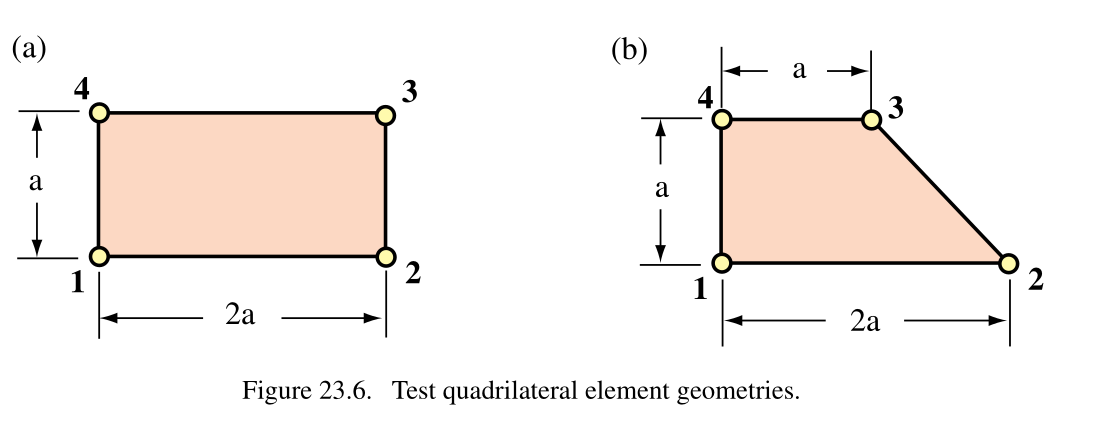


In [2]:
# Test of regular geometry

Em = 96
h = 1
a = 4
nu = 1/3 #poisson

# 2:1 rectangular geometry
ncoor = [(0,0),
         (2*a,0),
         (2*a,a),
         (0,a)]

Emat = [[Em/(1 - nu**2),    nu*Em/(1 - nu**2), 0],
        [nu*Em/(1 - nu**2), Em/(1 - nu**2),    0],
        [0, 0, Em*(1 - nu)/(2*(1 - nu**2))]]

p = 2 # 2 x 2 Gauss rule

Ke = Quad4IsoPMembraneStiffness(ncoor, [Emat, 0, 0], [h], (True, p))

Ke_np = np.array(Ke, dtype=float)

print(f"Gauss integration rule: {p} x {p}")
    
Ke_chop = np.where(np.abs(Ke) < 1e-10, 0.0, Ke)

print("Ke =")
print(Ke_chop)

eigvals = np.linalg.eigvalsh(Ke)
eigvals = np.where(np.abs(eigvals) < 1e-10, 0.0, eigvals)

print("Eigenvalues of Ke=")
print(eigvals)


Gauss integration rule: 2 x 2
Ke =
[[ 42.  18.  -6.   0. -21. -18. -15.   0.]
 [ 18.  78.   0.  30. -18. -39.   0. -69.]
 [ -6.   0.  42. -18. -15.   0. -21.  18.]
 [  0.  30. -18.  78.   0. -69.  18. -39.]
 [-21. -18. -15.   0.  42.  18.  -6.   0.]
 [-18. -39.   0. -69.  18.  78.   0.  30.]
 [-15.   0. -21.  18.  -6.   0.  42. -18.]
 [  0. -69.  18. -39.   0.  30. -18.  78.]]
Eigenvalues of Ke=
[  0.           0.           0.          42.          46.36027978
  78.          90.         223.63972022]


In [4]:
# Test of trapezoidal geometry

Em = 48*63*13*107
a = 4
h = 1
nu = 1/3 #poisson

# 2:1 rectangular geometry
ncoor = [(0,0),
         (2*a,0),
         (a, a),
         (0, a)]

Emat = [[Em/(1 - nu**2),    nu*Em/(1 - nu**2), 0],
        [nu*Em/(1 - nu**2), Em/(1 - nu**2),    0],
        [0, 0, Em*(1 - nu)/(2*(1 - nu**2))]]

for p in [1, 2, 3, 4]:
    Ke = Quad4IsoPMembraneStiffness(ncoor, [Emat, 0, 0], [h], (True, p))

    Ke_chop = np.where(np.abs(Ke) < 1e-10, 0.0, Ke)

    print("Ke =")
    print(Ke_chop)

    eigvals = np.linalg.eigvalsh(Ke)
    eigvals = np.where(np.abs(eigvals) < 1e-8, 0.0, eigvals)

    print("Eigenvalues of Ke =")
    print(eigvals)


Ke =
[[ 1840293.  1051596.  -262899.  -262899. -1840293. -1051596.   262899.
    262899.]
 [ 1051596.  3417687.  -262899.  1314495. -1051596. -3417687.   262899.
  -1314495.]
 [ -262899.  -262899.  1051596.  -525798.   262899.   262899. -1051596.
    525798.]
 [ -262899.  1314495.  -525798.  1051596.   262899. -1314495.   525798.
  -1051596.]
 [-1840293. -1051596.   262899.   262899.  1840293.  1051596.  -262899.
   -262899.]
 [-1051596. -3417687.   262899. -1314495.  1051596.  3417687.  -262899.
   1314495.]
 [  262899.   262899. -1051596.   525798.  -262899.  -262899.  1051596.
   -525798.]
 [  262899. -1314495.   525798. -1051596.  -262899.  1314495.  -525798.
   1051596.]]
Eigenvalues of Ke =
[      0.               0.               0.               0.
       0.         2268997.96239223 3680586.         8772760.03760777]
Ke =
[[ 2062746.  1092042.  -485352.  -303345. -1395387.  -970704.  -182007.
    182007.]
 [ 1092042.  3761478.  -303345.   970704.  -970704. -2730105.   182007.
 

In [6]:
def Quad4IsoPMembraneBodyForces(ncoor, mprop, fprop, options, bfor):
    """
    INPUT: ncoor (node coordinates), 
           mprop (material properties, given as list {Emat, rho, alpha}, note that Emat is 3x3 matrix), also rho and alpha are not used here)
           fprop (fabrication properties, i.e, thickness as four entry list, one entry list or empty list). If empty, it assumes uniform h = 1
           options (two item list, [numer, p], first isn't used here (its for symbolic op.), p specifies p points in each direction
           bfor (body forces per unit volume, either two item 1D list or 4 entry 2D list (at each corner)
    PROCESS:
    OUTPUT: fe as 8 x 1 array
    """
    if len(options) == 2:
        _, p = options
    else:
        p = 2

    th = 1.0
    
    if len(fprop) > 0:
        th = fprop[0]

    if len(bfor) == 2:
        bx, by = bfor
        bx1 = bx2 = bx3 = bx4 = bx
        by1 = by2 = by3 = by4 = by

    if len(bfor) == 4:
        (bx1, by1), (bx2, by2), (bx3, by3), (bx4, by4) = bfor
    
    if p < 1 or p>4:
        print("p out of range")
        return None

    # bxc and byc are never used, just reproduced here to be faithful to the original
    bxc = [bx1, bx2, bx3, bx4]
    byc = [by1, by2, by3, by4]
    
    fe = np.zeros(8)

    for k in range(1, p*p + 1):
        qcoor, w = QuadGaussRuleInfo(p, k)
        
        Nf, dNx, dNy, Jdet = Quad4IsoPShapeFunDer(ncoor, qcoor)

        bk = np.zeros(8)

        for i in range(4):
            bk[2*i]     = Nf[i] * bx
            bk[2*i + 1] = Nf[i] * by

        c = w * Jdet * th

        fe += c * bk

    return fe


def Quad4IsoPMembraneStresses(ncoor, mprop, fprop, options, udis):
    """
    INPUT: ncoor (node coordinates), 
           mprop (material properties, given as list {Emat, rho, alpha}, note that Emat is 3x3 matrix), also rho and alpha are not used here)
           fprop (fabrication properties, i.e, thickness as four entry list, one entry list or empty list). If empty, it assumes uniform h = 1
           options (two item list, [numer, p], first isn't used here (its for symbolic op.), p specifies p points in each direction
           udis (8 corner displacement components)
    PROCESS:
    OUTPUT: corner stresses
    """

    qctab = [
        [-1, -1],
        [ 1, -1],
        [ 1,  1],
        [-1,  1]
    ]
    
    Emat = np.asarray(mprop[0], dtype=float)
    
    ue = udis 
    if len(udis) == 4:
        ue = np.array(udis).flatten()

    ue = np.asarray(ue, dtype=float)


    sige = np.zeros((4, 3))

    for k in range(4):

        qcoor = qctab[k]

        Nf, dNx, dNy, Jdet = Quad4IsoPShapeFunDer(ncoor, qcoor)

        B = np.zeros((3, 8))

        for i in range(4):
            B[0, 2*i]     = dNx[i]
            B[1, 2*i + 1] = dNy[i]
            B[2, 2*i]     = dNy[i]
            B[2, 2*i + 1] = dNx[i]


        sige[k, :] = Emat @ (B @ ue)

    return sige